In [1]:
!pip3 install cf_xarray

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import cf_xarray # gives the ds.cf and da.cf objects
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from cmocean.tools import crop_by_percent
import gsw

import xgcm
from xgcm.autogenerate import generate_grid_ds

In [3]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='auto')
client

Client Scheduler: tcp://127.0.0.1:33119 Dashboard: http://127.0.0.1:8787/status,Cluster Workers: 4 Cores: 4 Memory: 16.75 GB


# Open data and create grid

In [4]:
from pathlib import Path
datadir = Path('../data/processed/')
datadirraw = Path('../data/raw/interp_monthly/')

In [5]:
def preprocess(ds):
    if 'Z' in ds.variables:
        ds['Z'] = - ds.Z
        ds = ds.rename({'Z':'depth'})
    return ds

ds = xr.open_mfdataset(datadirraw.glob('**/*.nc'), preprocess=preprocess).chunk({'time':1})
ds = generate_grid_ds(ds, {'Z':'depth'})
ds

<xarray.Dataset>
Dimensions:     (depth_left: 50, i: 720, j: 360, k: 50, nv: 2, time: 252)
Coordinates:
    longitude   (i) float64 dask.array<chunksize=(720,), meta=np.ndarray>
    latitude    (j) float64 dask.array<chunksize=(360,), meta=np.ndarray>
  * i           (i) int64 0 1 2 3 4 5 6 7 8 ... 712 713 714 715 716 717 718 719
  * j           (j) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * time        (time) datetime64[ns] 1997-01-16T12:00:00 ... 2017-12-16
    timestep    (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds   (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth       (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
  * k           (k) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
  * depth_left  (depth_left) float32 0.0 10.0 20.0 ... 4839.75 5250.25 5683.75
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH    (time, j, i) float64 dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SALT        (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
    THETA       (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
Attributes:
    product_time_coverage_start:  1992-01-01T12:00:00
    author:                       Ou Wang and Ian Fenty
    Insitution:                   JPL
    product_version:              ECCO Version 4 Release 4
    time_units:                   days since 1992-01-01 00:00:00
    Conventions:                  CF-1.6
    Project:                      Estimating the Circulation and Climate of t...
    cdm_data_type:                Grid
    geospatial_lon_units:         degrees_east
    Metadata_Conventions:         CF-1.6, Unidata Dataset Discovery v1.0, GDS...
    no_data:                      NaNf
    geospatial_lat_units:         degrees_north
    product_time_coverage_end:    2017-12-31T12:00:00
    geospatial_vertical_min:      -5906.25
    nz:                           50
    geospatial_vertical_units:    meter
    geospatial_vertical_max:      -5.0
    date_created:                 Thu Aug 22 18:56:33 2019
    time_coverage_start:          2013-12-01T00:00:00
    time_coverage_end:            2014-01-01T00:00:00

create the vertical metrics

In [6]:
grid = xgcm.Grid(ds, periodic=False)
grid

<xgcm.Grid>
T Axis (not periodic, boundary=None):
  * center   time
Y Axis (not periodic, boundary=None):
  * center   j
X Axis (not periodic, boundary=None):
  * center   i
Z Axis (not periodic, boundary=None):
  * center   k --> left
  * left     depth_left --> center

In [7]:
# Calculate vertical distances located on the cellboundary
ds.coords['dzc'] = grid.diff(ds.depth, 'Z', boundary='extrapolate')
# Calculate vertical distances located on the cellcenter
ds.coords['dzt'] = grid.diff(ds.depth_left, 'Z', boundary='extrapolate')

We save the new depth variable and metrics

In [8]:
ds[['dzc', 'dzt', 'depth_left']].to_netcdf(datadir / 'depth_metrics.nc')

We drop the bottom center point (necessary for the transform function)

In [9]:
ds = ds.isel(k=slice(None,-1))

Recreate the grid with the new metrics

In [10]:
grid = xgcm.Grid(ds, periodic=False, metrics={('Z',):['dzc', 'dzt']})
grid

<xgcm.Grid>
T Axis (not periodic, boundary=None):
  * center   time
Y Axis (not periodic, boundary=None):
  * center   j
X Axis (not periodic, boundary=None):
  * center   i
Z Axis (not periodic, boundary=None):
  * center   k --> outer
  * outer    depth_left --> center

# Compute the SCI at the bottom of the ML

## Compute thermodynamic properties

In [11]:
ds['SA'] = gsw.conversions.SA_from_SP(ds.SALT, ds.depth, ds.longitude, ds.latitude)
ds['CT'] = gsw.conversions.CT_from_pt(SA=ds.SA, pt=ds.THETA)
ds['alpha'] = gsw.density.alpha(SA=ds.SA, CT=ds.CT, p=ds.depth)
ds['beta']= gsw.density.beta(SA=ds.SA, CT=ds.CT, p=ds.depth)

Transform them at the bottom of the ML.

We follow the method imagined by Fabien Roquet: we compute a new variable phi=depth - MLD and we remap the SCI (or equvalent, T and S profiles) onto this new variable phi. We then get the value at e.g. 0 (bottom of the ML), 20 (20 meters under the ML), etc.

In [12]:
ds['phi_dep_mld_w'] = ds.depth_left - ds.MXLDEPTH
ds['phi_dep_mld_t'] = ds.depth - ds.MXLDEPTH

In [13]:
target = np.array([10, 30])

T = grid.transform(ds.CT, 'Z', target=target, target_data=ds.phi_dep_mld_t, method='linear')
S = grid.transform(ds.SA, 'Z', target=target, target_data=ds.phi_dep_mld_t, method='linear')
alpha = gsw.density.alpha(SA=S, CT=T, p=ds.MXLDEPTH + T.phi_dep_mld_t)
beta= gsw.density.beta(SA=S, CT=T, p=ds.MXLDEPTH + T.phi_dep_mld_t)

We compute the SCI:

$$
SCI = \left(\alpha  \frac{\partial T}{\partial z} + \beta  \frac{\partial S}{\partial z}\right) \cdot \left(\alpha  \frac{\partial T}{\partial z} - \beta  \frac{\partial S}{\partial z}\right)^{-1}
$$

In [14]:
g = 9.81
N2_T = g * alpha.mean('phi_dep_mld_t') * T.diff('phi_dep_mld_t').squeeze('phi_dep_mld_t') / (target[1] - target[0])
N2_S = - g * beta.mean('phi_dep_mld_t') * S.diff('phi_dep_mld_t').squeeze('phi_dep_mld_t') / (target[1] - target[0])

N2 = N2_T + N2_S
SCI = (N2_T - N2_S) / N2
SCI = SCI.rename('SCI')
SCI.attrs['long_name'] = 'Stratification Control Index'
SCI.attrs['unit'] = ''

CPU times: user 4.6 s, sys: 106 ms, total: 4.71 s
Wall time: 10.7 s


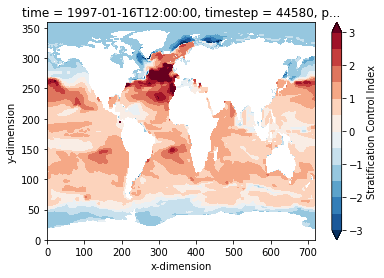

In [15]:
%%time
SCI.isel(time=0).plot.contourf(vmin=-3, vmax=3, cmap='RdBu_r', levels=np.arange(-3,3.5,.5))

Now we select the SCI at the month of the deepest ML

In [17]:
def get_deepest(SCI):
    return SCI.where(SCI.MXLDEPTH == SCI.MXLDEPTH.max('time'))
# for the function to work, we add MXLDEPTH in SCI coordinates
SCI.coords['MXLDEPTH'] = ds.MXLDEPTH

SCI_deepest = SCI.groupby('time.year').map(get_deepest)
# and drop again MXLDEPTH
SCI = SCI.drop_vars('MXLDEPTH')

Finally, we take the time mean, that corresponds to the deepest month, as it is a nanmean

In [19]:
SCI_mean = SCI_deepest.groupby('time.year').mean().rename('SCI_mean')
SCI_mean.attrs['long_name'] = 'stratification control index under the mixed layer'

CPU times: user 18 s, sys: 394 ms, total: 18.4 s
Wall time: 40.8 s


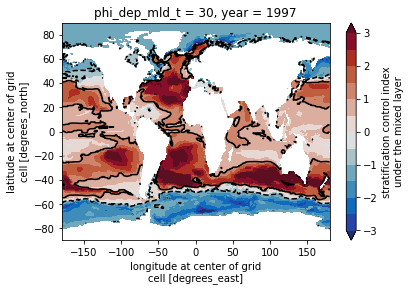

In [20]:
%%time 

SCI_mean.isel(year=0).plot.contourf(
    x='longitude', y='latitude',
    vmin=-3, vmax=3, cmap=crop_by_percent(cmo.balance, 10, which='both', N=None), levels=np.arange(-3,3.5,.5)
)
SCI_mean.isel(year=0).plot.contour(
    x='longitude', y='latitude',
    levels=[-1,1], colors='k'
)


Save the SCI

In [21]:
%%time
SCI_mean.to_netcdf(datadir / 'SCI_mean.nc')

CPU times: user 31.2 s, sys: 2.31 s, total: 33.5 s
Wall time: 4min 41s
